# calculate d200, d500, d1000

In [1]:
import os
import time
import numpy as np
import pandas as pd
import geopandas as gpd
import pyogrio
from scipy.spatial import cKDTree

# -------------------------------------------------------------------
# INPUTS
# -------------------------------------------------------------------
points_gdb = r"E:\World Bank deliverbale 1\wb_buildings\buildings_points_utm.gdb"
points_layer = "wb_buildings_extent_point"

knn_folder = r"E:\World Bank deliverbale 1\knn"
out_folder = os.path.join(knn_folder, "large_knn")
os.makedirs(out_folder, exist_ok=True)

out_csv = os.path.join(out_folder, "building_knn_large_k_summary.csv")

# -------------------------------------------------------------------
# READ POINTS
# -------------------------------------------------------------------
t0 = time.time()

gdf = pyogrio.read_dataframe(points_gdb, layer=points_layer)

print("Rows:", f"{len(gdf):,}")
print("Columns:", gdf.columns.tolist())
print("CRS:", gdf.crs)

# Use ORIG_FID as the building ID, based on your earlier join
if "ORIG_FID" not in gdf.columns:
    raise ValueError("ORIG_FID not found in point layer.")

# Extract coordinates
coords = np.column_stack([gdf.geometry.x.values, gdf.geometry.y.values]).astype("float64")

building_ids = pd.to_numeric(gdf["ORIG_FID"], errors="coerce").astype("Int64")

print("Coordinate array shape:", coords.shape)
print("Read time:", round(time.time() - t0, 2), "seconds")

Rows: 578,379
Columns: ['type', 'building', 'construction', 'area_m_utm', 'ORIG_FID', 'geometry']
CRS: EPSG:32636
Coordinate array shape: (578379, 2)
Read time: 23.07 seconds


# Build the KD-tree:

In [2]:
# -------------------------------------------------------------------
# BUILD KD-TREE
# -------------------------------------------------------------------
t0 = time.time()

tree = cKDTree(coords)

print("KD-tree built.")
print("Build time:", round(time.time() - t0, 2), "seconds")

KD-tree built.
Build time: 0.46 seconds


# Query the 200th, 500th, and 1000th nearest other buildings:

In [7]:
# -------------------------------------------------------------------
# QUERY DISTANCE TO 200th, 500th, AND 1000th NEAREST OTHER BUILDING
# -------------------------------------------------------------------

# Since the point itself is neighbor #1, use k+1.
# 201 = 200th other building
# 501 = 500th other building
# 1001 = 1000th other building
query_ranks = [201, 501, 1001, 2001, 4001, 8001]

t0 = time.time()

distances, indices = tree.query(
    coords,
    k=query_ranks,
    workers=-1
)

print("Query complete.")
print("Query time:", round(time.time() - t0, 2), "seconds")
print("Distances shape:", distances.shape)

Query complete.
Query time: 464.07 seconds
Distances shape: (578379, 6)


# Create the output table

In [8]:
large_knn = pd.DataFrame({
    "building_id": building_ids,
    "d200_near": distances[:, 0],
    "d500_near": distances[:, 1],
    "d1000_near": distances[:, 2],
    "d2000_near": distances[:, 3],
    "d4000_near": distances[:, 4],
    "d8000_near": distances[:, 5],
})

large_knn.to_csv(out_csv, index=False)

print("Exported:", out_csv)
large_knn.describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

Exported: E:\World Bank deliverbale 1\knn\large_knn\building_knn_large_k_summary.csv


,building_id,d200_near,d500_near,d1000_near,d2000_near,d4000_near,d8000_near
count,578379.0,578379.000000,578379.000000,578379.000000,578379.000000,578379.000000,578379.000000
mean,289190.0,149.553240,240.307203,348.321348,501.294662,716.859555,1021.817641
std,166963.780009,93.679168,146.890145,224.471190,313.851742,406.662425,514.512403
min,1.0,40.017457,68.401856,112.642138,208.989321,316.475520,549.844548
25%,144595.5,105.397021,169.882265,244.467075,352.337409,507.131811,732.631992
50%,289190.0,123.422368,197.885588,282.703160,404.029708,581.617653,843.060662
75%,433784.5,160.963732,259.134692,372.262331,534.040039,769.786181,1112.065276
90%,520541.2,228.076155,365.327013,528.276493,768.024664,1105.217704,1578.833429
95%,549460.1,286.811694,460.317240,662.959114,964.543012,1372.066823,1895.073238
99%,572595.22,560.704155,888.880297,1330.137146,1851.937411,2482.016670,3178.354097


Rows used for plotting: 200,000


C:\Users\Alex Blei\AppData\Local\Temp\ipykernel_24484\3465658025.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=labels, showfliers=False)


NameError: name 'plot_folder' is not defined

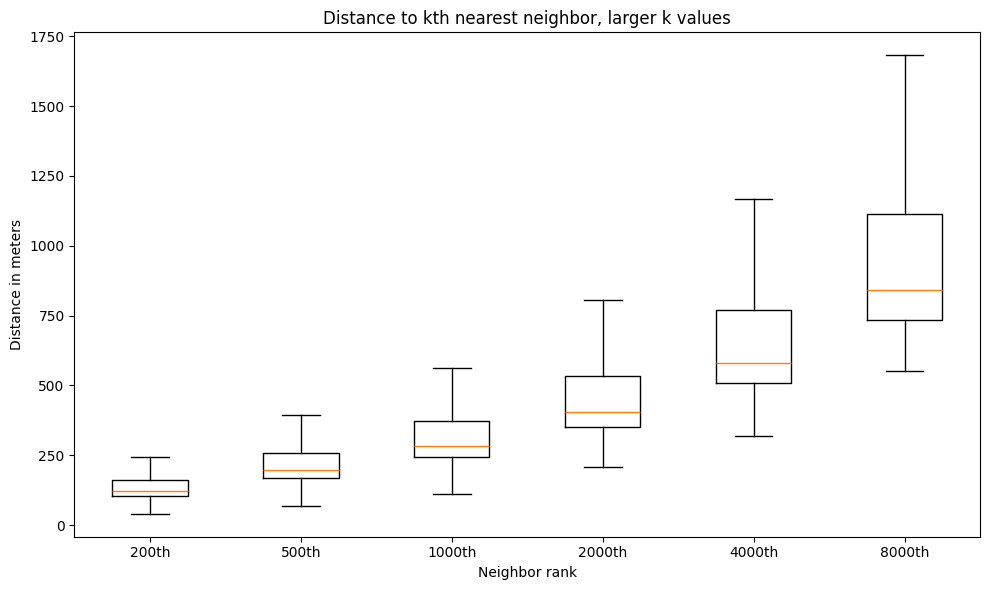

In [9]:
import os
import matplotlib.pyplot as plt

# Distance columns from the large-k nearest neighbor table
large_dist_cols = [
    "d200_near",
    "d500_near",
    "d1000_near",
    "d2000_near",
    "d4000_near",
    "d8000_near",
]

# Optional: sample for plotting if the dataset is large
plot_df = large_knn.copy()

sample_size = 200_000
if len(plot_df) > sample_size:
    plot_df_sample = plot_df.sample(sample_size, random_state=42)
else:
    plot_df_sample = plot_df

print("Rows used for plotting:", f"{len(plot_df_sample):,}")

# Prepare data and labels
box_data = [plot_df_sample[col].dropna() for col in large_dist_cols]

labels = [
    col.replace("d", "").replace("_near", "th")
    for col in large_dist_cols
]

# Create boxplot
plt.figure(figsize=(10, 6))
plt.boxplot(box_data, labels=labels, showfliers=False)
plt.xlabel("Neighbor rank")
plt.ylabel("Distance in meters")
plt.title("Distance to kth nearest neighbor, larger k values")
plt.tight_layout()

out_png = os.path.join(plot_folder, "boxplot_large_k_distance_to_kth_neighbor.png")
plt.savefig(out_png, dpi=200)
plt.show()

print("Saved:", out_png)